In [1]:
# ================= STEP 1: LOAD DATA =================
#import required libraries
import pandas as pd
import numpy as np
df=pd.read_csv("/content/3) Sentiment dataset.csv")

In [2]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [3]:
# Set as index
df.set_index('Timestamp', inplace=True)

In [4]:
# ================= CLEAN SENTIMENT =================

# Convert to string, remove spaces, lowercase
df['Sentiment'] = df['Sentiment'].astype(str).str.strip().str.lower()


In [5]:
# List of words representing positive sentiment

positive_words = [
    'positive','joy','happiness','love','gratitude','excitement','admiration',
    'amusement','hope','optimism','pride','kindness','delight','blessed',
    'contentment','enthusiasm','affection','inspiration','confidence','happy'
]
# List of words representing negative sentiment
negative_words = [
    'negative','anger','fear','sadness','disgust','grief','loneliness',
    'jealousy','frustration','anxiety','regret','hate','bad','despair',
    'boredom','pain','suffering','sad'
]

# # Function to convert detailed emotions into 3 categories
def convert_sentiment(text):
    # Check if any positive word is present
    for word in positive_words:
        if word in text:
            return 1  # Positive
  # Check if any negative word is present
    for word in negative_words:
        if word in text:
            return -1  # Negative
    return 0  # Neutral

# Apply conversion function on 'Sentiment' column
df['Sentiment'] = df['Sentiment'].apply(convert_sentiment)

# Verify conversion result
print("Unique values after conversion:", df['Sentiment'].unique())

Unique values after conversion: [ 1 -1  0]


In [6]:
# # Resample data on daily basis and calculate average sentiment

daily_data = df['Sentiment'].resample('D').mean()

# Fill missing values using forward fill method
daily_data = daily_data.fillna(method='ffill')
#Display first few rows
print(daily_data.head())

Timestamp
2010-05-15    0.0
2010-05-16    0.0
2010-05-17    0.0
2010-05-18    0.0
2010-05-19    0.0
Freq: D, Name: Sentiment, dtype: float64


/tmp/ipykernel_13041/3754781961.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_data = daily_data.fillna(method='ffill')


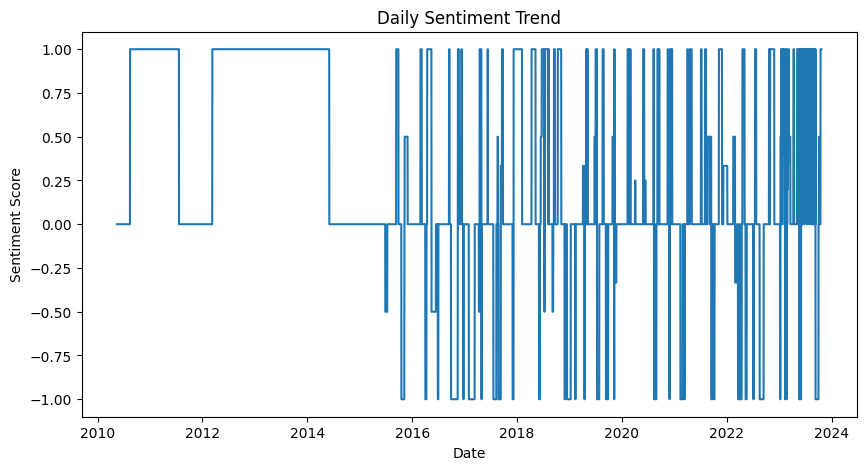

In [7]:
import matplotlib.pyplot as plt
# Plot daily sentiment trend
plt.figure(figsize=(10,5))
plt.plot(daily_data)
# Add title and labels
plt.title("Daily Sentiment Trend")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
# Show plot
plt.show()

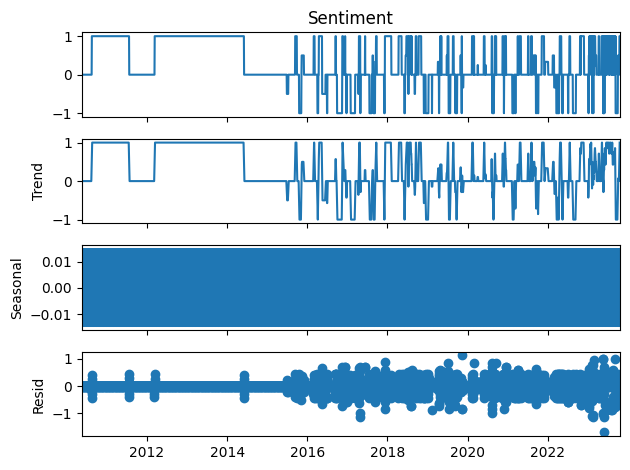

In [8]:
#Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
# Decompose time series into trend, seasonal, and residual components
decomposition = seasonal_decompose(daily_data, model='additive')
# Plot decomposition
decomposition.plot()
plt.show()

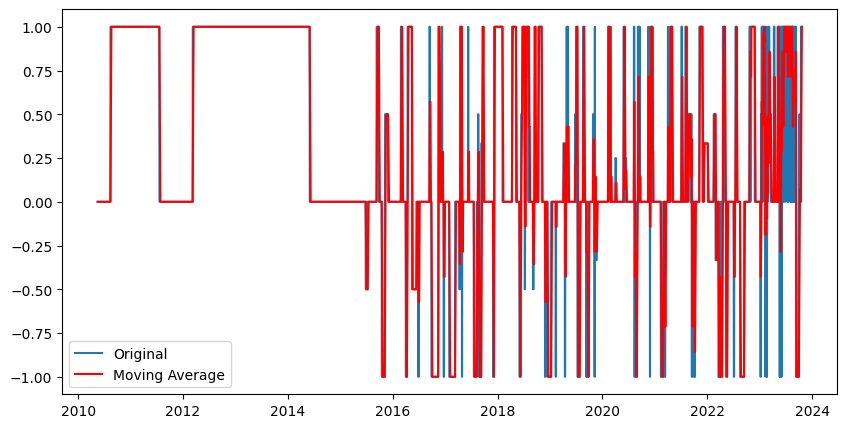

In [9]:
#Moving Average
# Calculate 7-day moving average
moving_avg = daily_data.rolling(window=7).mean()
# Plot original data and moving average
plt.figure(figsize=(10,5))
plt.plot(daily_data, label='Original')
plt.plot(moving_avg, label='Moving Average', color='red')
# Add legend
plt.legend()
plt.show()

In [10]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Build exponential smoothing model with trend component
model_exp = ExponentialSmoothing(daily_data, trend='add')
# Fit the model
fit_exp = model_exp.fit()
# Forecast next 7 days
forecast_exp = fit_exp.forecast(7)
print("Exponential Forecast:\n", forecast_exp)

Exponential Forecast:
 2023-10-23    1.000241
2023-10-24    1.000445
2023-10-25    1.000649
2023-10-26    1.000853
2023-10-27    1.001056
2023-10-28    1.001260
2023-10-29    1.001464
Freq: D, dtype: float64


In [11]:
#Train _test split
train = daily_data[:int(0.8*len(daily_data))]
test = daily_data[int(0.8*len(daily_data)):]

In [12]:
#ARIMA Model
from statsmodels.tsa.arima.model import ARIMA
#Build ARIMA model with (p=1, d=1, q=1)
model = ARIMA(train, order=(1,1,1))
# Fit model
model_fit = model.fit()
# Forecast for test data length
forecast = model_fit.forecast(steps=len(test))

In [13]:
from sklearn.metrics import mean_squared_error
import numpy as np
# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(test, forecast))
# Print RMSE value
print("RMSE:", rmse)

RMSE: 0.6483116817850756


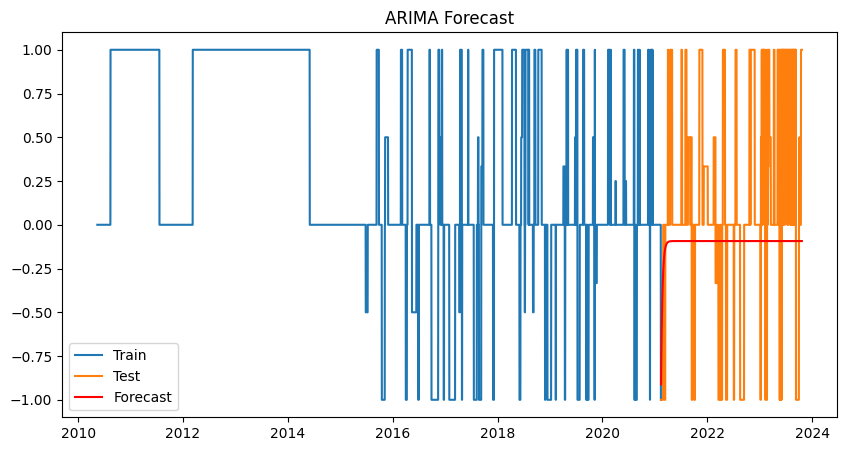

In [14]:
# Plot train, test, and forecast data
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast', color='red')
# Add legend and title
plt.legend()
plt.title("ARIMA Forecast")
# Show plot
plt.show()


In [15]:
#objective: Analyze sentiment trends and forecast future values.

#Dataset: Social media data with timestamp and sentiment labels.

#Preprocessing: Cleaned sentiment column and converted into 1 (positive), 0 (neutral), -1 (negative).

#Time Series: Resampled data on daily basis and handled missing values.

#Visualization: Plotted line graph to observe sentiment trends.

#Decomposition: Broke series into trend, seasonality, and residual components.

#Moving Average: Applied to smooth the data.

#Exponential Smoothing: Used for short-term forecasting.

#ARIMA Model: Applied for prediction of future values.

#Evaluation: Model performance measured using RMSE.

#Conclusion: Time series techniques successfully analyzed and predicted sentiment patterns.